# Job Shop Scheduling Problem (JSSP)
## Formulação Disjuntiva MIP — Resolvido com Gurobi

**Artigo de referência:**  
King & Hildebrand (2024). *Job Shop Scheduling with Integer Programming, Shifting Bottleneck, and Decision Diagrams: A Computational Study.*  
arXiv: https://arxiv.org/abs/2407.18111

**Dados (instâncias benchmark públicas):**  
Fisher & Thompson (1963) — disponíveis em: https://github.com/tamy0612/JSPLIB

---

## O que é o JSSP?

Imagine uma fábrica com **n jobs (tarefas)** e **m máquinas**.  
Cada job tem uma **sequência fixa de operações**, e cada operação precisa de uma máquina específica por um tempo determinado.  

**Restrições:**
- Cada máquina só processa **um job por vez**
- As operações de um mesmo job devem respeitar a **ordem de precedência**
- Não pode haver interrupção (sem preempção)

**Objetivo:** minimizar o **makespan** — o tempo total até que todos os jobs sejam concluídos.

---

## Instância utilizada: FT06

A instância **FT06** de Fisher & Thompson (1963) é um benchmark clássico:  
- **6 jobs** e **6 máquinas**  
- **Solução ótima conhecida:** makespan = **55**  




In [3]:
pip install gurobipy matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


---
### Passo 2 — Dados da instância

O formato dos dados é: cada linha representa um job.  
Os valores alternam entre **número da máquina** e **tempo de processamento**.  

Por exemplo: `0 3 1 2 2 2` significa:  
- Operação 1: máquina 0, duração 3  
- Operação 2: máquina 1, duração 2  
- Operação 3: máquina 2, duração 2  


In [ ]:
import os


INSTANCIA = "ft06" #Pode trocar a Instãncia para ft10, ft20, la01, la02, la03, la04, la05, la06, la07, la08, la09, la10, abz5 ou abz6


PASTA = os.path.join(os.path.dirname(os.path.abspath("__file__")), "instances")

# Ótimos conhecidos da literatura (para validação automática)
OTIMOS = {
    "ft06": 55,   "ft10": 930,  "ft20": 1165,
    "la01": 666,  "la02": 655,  "la03": 597,
    "la04": 590,  "la05": 593,  "la06": 926,
    "la07": 890,  "la08": 863,  "la09": 951,
    "la10": 958,  "abz5": 1234, "abz6": 943,
}

# PARSER — lê qualquer arquivo no formato JSPLIB
def carregar_instancia(pasta, nome):
    caminho = os.path.join(pasta, nome)  

    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f"Arquivo nao encontrado: '{caminho}'\n"
            f"Verifique se a pasta e o nome da instancia estao corretos."
        )

    jobs_data      = []
    n_jobs         = 0
    n_machines     = 0
    cabecalho_lido = False

    with open(caminho, "r") as f:
        for linha in f:
            linha = linha.strip()

            if (not linha
                    or linha.startswith("#")
                    or linha.startswith("+")
                    or linha.startswith("(")):
                continue

            numeros = list(map(int, linha.split()))

            if not cabecalho_lido:
                n_jobs, n_machines = numeros[0], numeros[1]
                cabecalho_lido = True
                continue

            if len(numeros) >= 2:
                ops = []
                for k in range(0, len(numeros) - 1, 2):
                    ops.append((numeros[k], numeros[k + 1]))
                if ops:
                    jobs_data.append(ops)

            if len(jobs_data) == n_jobs:
                break

    return jobs_data, n_jobs, n_machines


jobs_data, n_jobs, n_machines = carregar_instancia(PASTA, INSTANCIA)
OTIMO_CONHECIDO = OTIMOS.get(INSTANCIA, None)

print(f"Instância carregada : {INSTANCIA.upper()}")
print(f"  Jobs              : {n_jobs}")
print(f"  Máquinas          : {n_machines}")
print(f"  Ótimo conhecido   : {OTIMO_CONHECIDO if OTIMO_CONHECIDO else 'não cadastrado'}")
print()
print("Estrutura dos jobs (maquina, duracao):")
for i, job in enumerate(jobs_data):
    ops = " -> ".join(f"M{m}({t})" for m, t in job)
    print(f"  Job {i}: {ops}")

Instância carregada : FT06
  Jobs              : 6
  Máquinas          : 6
  Ótimo conhecido   : 55

Estrutura dos jobs (maquina, duracao):
  Job 0: M2(1) -> M0(3) -> M1(6) -> M3(7) -> M5(3) -> M4(6)
  Job 1: M1(8) -> M2(5) -> M4(10) -> M5(10) -> M0(10) -> M3(4)
  Job 2: M2(5) -> M3(4) -> M5(8) -> M0(9) -> M1(1) -> M4(7)
  Job 3: M1(5) -> M0(5) -> M2(5) -> M3(3) -> M4(8) -> M5(9)
  Job 4: M2(9) -> M1(3) -> M4(5) -> M5(4) -> M0(3) -> M3(1)
  Job 5: M1(3) -> M3(3) -> M5(9) -> M0(10) -> M4(4) -> M2(1)


---
## Passo 3 — Formulação Matemática (Disjuntiva de Manne, 1960)

### Variáveis de decisão
| Variável | Tipo | Significado |
|---|---|---|
| $S_{ij}$ | Contínua ≥ 0 | Tempo de **início** da operação $j$ do job $i$ |
| $x_{ijkl}$ | Binária {0,1} | 1 se $(i,j)$ ocorre **antes** de $(k,l)$ na mesma máquina |
| $C_{max}$ | Contínua ≥ 0 | **Makespan** (variável a minimizar) |

### Modelo completo

$$\min \quad C_{max}$$

$$S_{i,j+1} \geq S_{ij} + p_{ij} \qquad \forall\, i,\, j < |J_i|-1 \tag{1 - Precedência}$$

$$S_{kl} \geq S_{ij} + p_{ij} - V(1 - x_{ijkl}) \qquad \forall\,(i,j),(k,l) \text{ na mesma máquina} \tag{2a - Disjunção}$$

$$S_{ij} \geq S_{kl} + p_{kl} - V\,x_{ijkl} \qquad \forall\,(i,j),(k,l) \text{ na mesma máquina} \tag{2b - Disjunção}$$

$$C_{max} \geq S_{i,\text{last}} + p_{i,\text{last}} \qquad \forall\, i \tag{3 - Makespan}$$

### Por que Big-M funciona?
Nas restrições (2a) e (2b), o Big-M $V$ serve para **desativar** uma das restrições:
- Se $x=1$: (2a) fica ativa (garante que $(i,j)$ precede $(k,l)$) e (2b) é desativada  
- Se $x=0$: (2b) fica ativa (garante que $(k,l)$ precede $(i,j)$) e (2a) é desativada  

O solver decide o valor de cada $x$ para minimizar o makespan.

---
## Passo 4 — Implementação do Modelo com Gurobi

In [ ]:
import gurobipy as gp
from gurobipy import GRB
from collections import defaultdict
import time

# Big-M = soma de todos os tempos (pior caso trivial)
V = sum(t for job in jobs_data for (_, t) in job)
print(f"Big-M (V) = {V}")

# Para cada máquina, quais operações (i,j) a utilizam?
machine_ops = defaultdict(list)
for i, job in enumerate(jobs_data):
    for j, (m, _) in enumerate(job):
        machine_ops[m].append((i, j))

# CRIAR MODELO
model = gp.Model(f"JSSP_{INSTANCIA.upper()}")
model.setParam("OutputFlag", 1)
model.setParam("TimeLimit", 300)   # 5 minutos máximo

# Variáveis de início S[i,j]
S = {
    (i, j): model.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"S_{i}_{j}")
    for i, job in enumerate(jobs_data)
    for j in range(len(job))
}

# Makespan
C_max = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="C_max")

# Variáveis disjuntivas x[i,j,k,l]
x = {}
for m, ops in machine_ops.items():
    for a in range(len(ops)):
        for b in range(a + 1, len(ops)):
            i, j = ops[a]
            k, l = ops[b]
            x[i, j, k, l] = model.addVar(vtype=GRB.BINARY, name=f"x_{i}{j}{k}{l}")

# FUNÇÃO OBJETIVO
model.setObjective(C_max, GRB.MINIMIZE)

# RESTRIÇÃO (1): Precedência intra-job
# Operação j+1 só começa depois que a operação j terminar
for i, job in enumerate(jobs_data):
    for j in range(len(job) - 1):
        _, p = job[j]
        model.addConstr(S[i, j+1] >= S[i, j] + p,
                        name=f"prec_{i}_{j}")

# RESTRIÇÃO (2): Disjunção — sem sobreposição na mesma máquina
# Para cada par de operações na mesma máquina:
#   x=1 → (i,j) antes de (k,l): S[k,l] >= S[i,j] + p_ij
#   x=0 → (k,l) antes de (i,j): S[i,j] >= S[k,l] + p_kl
for m, ops in machine_ops.items():
    for a in range(len(ops)):
        for b in range(a + 1, len(ops)):
            i, j = ops[a]
            k, l = ops[b]
            p_ij = jobs_data[i][j][1]
            p_kl = jobs_data[k][l][1]
            var  = x[i, j, k, l]

            model.addConstr(
                S[k, l] >= S[i, j] + p_ij - V * (1 - var),
                name=f"disj1_{m}_{i}{j}_{k}{l}"
            )
            model.addConstr(
                S[i, j] >= S[k, l] + p_kl - V * var,
                name=f"disj2_{m}_{i}{j}_{k}{l}"
            )

# RESTRIÇÃO (3): Makespan
# C_max >= término de toda última operação de cada job
for i, job in enumerate(jobs_data):
    last = len(job) - 1
    model.addConstr(
        C_max >= S[i, last] + job[last][1],
        name=f"cmax_{i}"
    )

print(f"\nModelo construído com sucesso!")
print(f"  Variáveis binárias (x)    : {len(x)}")
print(f"  Variáveis contínuas (S+Cm): {len(S) + 1}")
print(f"  Restrições totais         : {model.NumConstrs}")

Big-M (V) = 197
Restricted license - for non-production use only - expires 2027-11-29
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300

Modelo construído com sucesso!
  Variáveis binárias (x)    : 90
  Variáveis contínuas (S+Cm): 37
  Restrições totais         : 0


---
## Passo 5 — Resolver o Modelo

In [7]:
t0 = time.time()
model.optimize()
tempo = time.time() - t0

print("\n" + "="*55)
if model.Status == GRB.OPTIMAL:
    print("  STATUS: SOLUCAO OTIMA ENCONTRADA")
elif model.Status == GRB.TIME_LIMIT and model.SolCount > 0:
    print("  STATUS: Melhor solucao (limite de tempo atingido)")
else:
    print("  STATUS: Sem solucao viavel")
    raise SystemExit()

makespan = C_max.X
gap      = model.MIPGap * 100

print(f"  Makespan encontrado : {makespan:.0f}")
if OTIMO_CONHECIDO:
    print(f"  Otimo conhecido     : {OTIMO_CONHECIDO}")
print(f"  MIP Gap             : {gap:.2f}%")
print(f"  Tempo de solucao    : {tempo:.3f}s")
print(f"  Nos B&B explorados  : {int(model.NodeCount)}")
print("="*55)

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 24.04.4 LTS")

CPU model: AMD Ryzen 7 5700U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 216 rows, 127 columns and 612 nonzeros (Min)
Model fingerprint: 0xf8bbfdf3
Model has 1 linear objective coefficients
Variable types: 37 continuous, 90 integer (90 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+02]

Presolve time: 0.03s
Presolved: 216 rows, 127 columns, 612 nonzeros
Variable types: 37 continuous, 90 integer (90 binary)
Found heuristic solution: objective 170.0000000

Root relaxation: objective 4.700000e+01, 60 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth In

---
## Passo 6 — Gráfico de Gantt

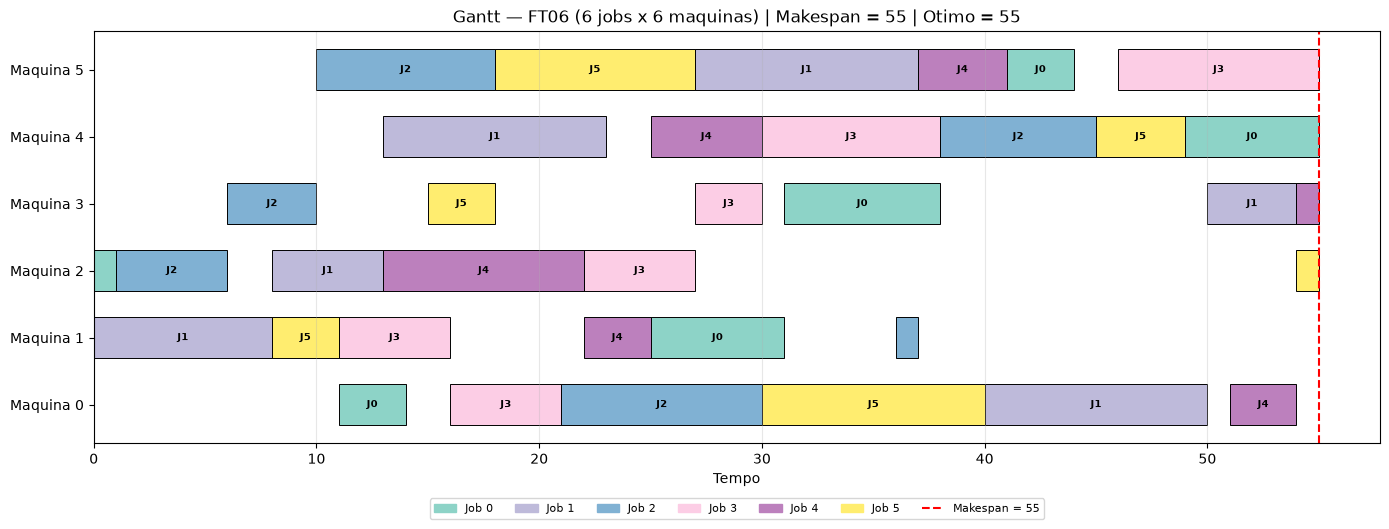

Grafico salvo como 'gantt_ft06.png'


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

schedule = [
    (i, j, jobs_data[i][j][0], S[i, j].X, jobs_data[i][j][1])
    for i, job in enumerate(jobs_data)
    for j in range(len(job))
]

cores = plt.cm.Set3(np.linspace(0, 1, n_jobs))
altura = max(5, n_machines * 0.9)
fig, ax = plt.subplots(figsize=(14, altura))

for (i, j, m, start, p) in schedule:
    ax.barh(y=m, width=p, left=start, height=0.6,
            color=cores[i], edgecolor='black', linewidth=0.7)
    # Label dentro da barra só se houver espaço
    if p > makespan * 0.04:
        ax.text(start + p/2, m, f'J{i}',
                ha='center', va='center', fontsize=7, fontweight='bold')

ax.axvline(x=makespan, color='red', linestyle='--', linewidth=1.5)
ax.set_yticks(range(n_machines))
ax.set_yticklabels([f'Maquina {m}' for m in range(n_machines)])
ax.set_xlabel('Tempo')
titulo = f'Gantt — {INSTANCIA.upper()} ({n_jobs} jobs x {n_machines} maquinas) | Makespan = {makespan:.0f}'
if OTIMO_CONHECIDO:
    titulo += f' | Otimo = {OTIMO_CONHECIDO}'
ax.set_title(titulo)
ax.grid(axis='x', alpha=0.3)

patches = [mpatches.Patch(color=cores[i], label=f'Job {i}') for i in range(n_jobs)]
patches.append(plt.Line2D([0], [0], color='red', linestyle='--',
                           label=f'Makespan = {makespan:.0f}'))
ncols = min(n_jobs + 1, 8)
ax.legend(handles=patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.12), ncol=ncols, fontsize=8)

plt.tight_layout()
nome_png = f"gantt_{INSTANCIA}.png"
plt.savefig(nome_png, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafico salvo como '{nome_png}'")

---
## Passo 7 — Verificação de Factibilidade

In [9]:
ok    = True
erros = []

# Verificar precedência intra-job
for i, job in enumerate(jobs_data):
    for j in range(len(job) - 1):
        _, p = job[j]
        if S[i, j+1].X < S[i, j].X + p - 1e-6:
            erros.append(f"[ERRO] Precedencia violada: Job {i}, Op {j} -> {j+1}")
            ok = False

# Verificar não-sobreposição
for m, ops in machine_ops.items():
    for a in range(len(ops)):
        for b in range(a + 1, len(ops)):
            i, j = ops[a]
            k, l = ops[b]
            s1, p1 = S[i, j].X, jobs_data[i][j][1]
            s2, p2 = S[k, l].X, jobs_data[k][l][1]
            sobreposicao = not (s1 + p1 <= s2 + 1e-6 or s2 + p2 <= s1 + 1e-6)
            if sobreposicao:
                erros.append(f"[ERRO] Sobreposicao: Maquina {m}, ops ({i},{j}) e ({k},{l})")
                ok = False

print("VERIFICACAO DE FACTIBILIDADE:")
print("-" * 45)
if ok:
    print("OK - Todas as precedencias respeitadas")
    print("OK - Nenhuma sobreposicao nas maquinas")
    print(f"OK - Makespan = {makespan:.0f}")
    if OTIMO_CONHECIDO:
        if abs(makespan - OTIMO_CONHECIDO) < 1e-3:
            print(f"OK - Solucao OTIMA confirmada (GAP = 0.00%)")
        else:
            diff = abs(makespan - OTIMO_CONHECIDO) / OTIMO_CONHECIDO * 100
            print(f"   GAP em relacao ao otimo: {diff:.2f}%")
else:
    for e in erros:
        print(e)

print()
print("="*55)
print(f"  RESUMO FINAL — {INSTANCIA.upper()}")
print("="*55)
print(f"  Instancia    : {n_jobs} jobs x {n_machines} maquinas")
print(f"  Makespan     : {makespan:.0f}")
if OTIMO_CONHECIDO:
    print(f"  Otimo lit.   : {OTIMO_CONHECIDO}")
print(f"  MIP Gap      : {gap:.2f}%")
print(f"  Tempo        : {tempo:.3f}s")
print(f"  Variaveis bin: {len(x)}")
print(f"  Restricoes   : {model.NumConstrs}")
print("="*55)

VERIFICACAO DE FACTIBILIDADE:
---------------------------------------------
OK - Todas as precedencias respeitadas
OK - Nenhuma sobreposicao nas maquinas
OK - Makespan = 55
OK - Solucao OTIMA confirmada (GAP = 0.00%)

  RESUMO FINAL — FT06
  Instancia    : 6 jobs x 6 maquinas
  Makespan     : 55
  Otimo lit.   : 55
  MIP Gap      : 0.00%
  Tempo        : 0.474s
  Variaveis bin: 90
  Restricoes   : 216


---
## Referências
- **King & Hildebrand (2024)** — https://arxiv.org/abs/2407.18111
- **Manne (1960)** — On the Job Shop Scheduling Problem. *Operations Research*, 8(2)
- **Fisher & Thompson (1963)** — Probabilistic Learning Combinations of Local Job-Shop Scheduling Rules
- **Instâncias:** https://github.com/tamy0612/JSPLIB